# Task 3: Reinforcement Learning Agent for Loan Approval

**Project**: Policy Optimization for Financial Decision-Making  
**Author**: Shreyansh Singh  
**Date**: October 2025

---

## Objective
Build a Reinforcement Learning agent to optimize loan approval decisions:
1. Define RL environment (states, actions, rewards)
2. Create financial reward function
3. Train policy using offline RL (historical data)
4. Evaluate expected policy value ($/loan)
5. Analyze agent's decision patterns
6. Compare with Deep Learning model

---

## Key Difference from Task 2

### Deep Learning Model (Task 2):
- **Goal**: Predict default probability
- **Metric**: AUC-ROC (classification accuracy)
- **Optimization**: Maximize correct predictions
- **Decision**: Binary (default/paid)

### RL Agent (Task 3):
- **Goal**: Maximize financial return
- **Metric**: Expected Value ($/loan)
- **Optimization**: Maximize profit
- **Decision**: Action-based (approve/deny)

**This fundamental difference drives different approval strategies!**

In [125]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import json
import joblib
from tqdm import tqdm
import time
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [126]:
# Setup paths
PROJECT_ROOT = Path('.').absolute().parent
DATA_DIR = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR = PROJECT_ROOT / 'models'
FIGURES_DIR = PROJECT_ROOT / 'figures'

print("Directories ready!")
print(f"Data: {DATA_DIR}")
print(f"Models: {MODELS_DIR}")

Directories ready!
Data: /Users/shreyanshsingh/Downloads/Shodh AI/Projects/loan-policy-optimization/data/processed
Models: /Users/shreyanshsingh/Downloads/Shodh AI/Projects/loan-policy-optimization/models


## 1. Load Data and Loan Details

We need:
- Features (X)
- Labels (y) - loan outcomes
- Loan amounts and interest rates - for reward calculation

In [128]:
# Load preprocessed data (unscaled for RL)
print("Loading preprocessed data...")

X_train = pd.read_csv(DATA_DIR / 'X_train.csv')
X_val = pd.read_csv(DATA_DIR / 'X_val.csv')
X_test = pd.read_csv(DATA_DIR / 'X_test.csv')

y_train = pd.read_csv(DATA_DIR / 'y_train.csv').values.ravel()
y_val = pd.read_csv(DATA_DIR / 'y_val.csv').values.ravel()
y_test = pd.read_csv(DATA_DIR / 'y_test.csv').values.ravel()

print(f"Data loaded!")
print(f"Train: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}")

Loading preprocessed data...
Data loaded!
Train: (489981, 21)
Val:   (105018, 21)
Test:  (105000, 21)


In [129]:
# Load full cleaned dataset to get loan amounts and interest rates
df_cleaned = pd.read_csv(DATA_DIR / 'df_cleaned.csv')

print(f"Full cleaned dataset loaded: {df_cleaned.shape}")
print(f"\nChecking for loan_amnt and int_rate columns:")
print(f"loan_amnt present: {'loan_amnt' in df_cleaned.columns}")
print(f"int_rate present: {'int_rate' in df_cleaned.columns}")

Full cleaned dataset loaded: (699999, 29)

Checking for loan_amnt and int_rate columns:
loan_amnt present: True
int_rate present: True


## 2. Define RL Environment

### Components:
1. **State**: Loan application features (21 features)
2. **Action**: {0: Deny, 1: Approve}
3. **Reward**: Financial outcome based on loan result

### Reward Function:
```python
if action == DENY:
    reward = 0  # No profit, no loss
    
elif action == APPROVE:
    if loan_status == PAID:
        # Profit = Interest earned
        reward = loan_amount * (int_rate / 100) * (term / 12)
    else:  # DEFAULT
        # Loss = Principal lost (assume 0% recovery for simplicity)
        reward = -loan_amount
```

In [131]:
def calculate_reward(loan_amount, int_rate, term, loan_status, action):
    """
    Calculate financial reward for RL agent
    
    Parameters:
    -----------
    loan_amount : float
        Principal loan amount
    int_rate : float
        Annual interest rate (%)
    term : int
        Loan term in months
    loan_status : int
        0 = Paid, 1 = Default
    action : int
        0 = Deny, 1 = Approve
    
    Returns:
    --------
    reward : float
        Financial reward/penalty
    """
    if action == 0:  # DENY
        return 0.0
    
    else:  # APPROVE (action == 1)
        if loan_status == 0:  # PAID
            # Profit = Interest earned over loan term
            # Simplified: loan_amount * annual_rate * (years)
            profit = loan_amount * (int_rate / 100) * (term / 12)
            return profit
        else:  # DEFAULT (loan_status == 1)
            # Loss = Principal (assuming 0% recovery)
            loss = -loan_amount
            return loss

# Test the reward function
print("Testing reward function:")
print(f"\nScenario 1: Deny loan")
print(f"Reward: ${calculate_reward(10000, 12, 36, 0, action=0):,.2f}")

print(f"\nScenario 2: Approve loan, borrower pays back")
print(f"Reward: ${calculate_reward(10000, 12, 36, loan_status=0, action=1):,.2f}")

print(f"\nScenario 3: Approve loan, borrower defaults")
print(f"Reward: ${calculate_reward(10000, 12, 36, loan_status=1, action=1):,.2f}")

print("\nReward function defined")

Testing reward function:

Scenario 1: Deny loan
Reward: $0.00

Scenario 2: Approve loan, borrower pays back
Reward: $3,600.00

Scenario 3: Approve loan, borrower defaults
Reward: $-10,000.00

Reward function defined


## 3. Prepare Data with Rewards

We'll use **offline RL** approach:
- We have historical data (states, actions, outcomes)
- We know which loans were approved (action = 1) and their outcomes
- We'll train a policy that maximizes expected reward

In [133]:
# Get indices for train, val, test splits (they should match the splits from Task 1)
# We'll use the first N rows as train, next M as val, last K as test
n_train = len(X_train)
n_val = len(X_val)
n_test = len(X_test)

print(f"Split sizes: Train={n_train}, Val={n_val}, Test={n_test}")
print(f"Total: {n_train + n_val + n_test}")
print(f"Cleaned df: {len(df_cleaned)}")

# The df_cleaned should have same order as our splits
# Extract loan details for each split
train_loan_amnt = df_cleaned['loan_amnt'].iloc[:n_train].values
train_int_rate = df_cleaned['int_rate'].iloc[:n_train].values
train_term = df_cleaned['term'].iloc[:n_train].values

val_loan_amnt = df_cleaned['loan_amnt'].iloc[n_train:n_train+n_val].values
val_int_rate = df_cleaned['int_rate'].iloc[n_train:n_train+n_val].values
val_term = df_cleaned['term'].iloc[n_train:n_train+n_val].values

test_loan_amnt = df_cleaned['loan_amnt'].iloc[n_train+n_val:].values
test_int_rate = df_cleaned['int_rate'].iloc[n_train+n_val:].values
test_term = df_cleaned['term'].iloc[n_train+n_val:].values

print("\nLoan details extracted for all splits")

Split sizes: Train=489981, Val=105018, Test=105000
Total: 699999
Cleaned df: 699999

Loan details extracted for all splits


In [134]:
# Calculate potential rewards for APPROVE action on training data
# This helps us understand the reward distribution

train_rewards_if_approve = np.array([
    calculate_reward(amt, rate, term, status, action=1)
    for amt, rate, term, status in zip(train_loan_amnt, train_int_rate, train_term, y_train)
])

print("Reward Distribution Analysis (if all loans were approved):")
print(f"\nTotal loans: {len(train_rewards_if_approve):,}")
print(f"Paid loans: {(y_train == 0).sum():,} ({(y_train == 0).sum() / len(y_train) * 100:.1f}%)")
print(f"Default loans: {(y_train == 1).sum():,} ({(y_train == 1).sum() / len(y_train) * 100:.1f}%)")

print(f"\nReward Statistics:")
print(f"Mean reward: ${train_rewards_if_approve.mean():,.2f}")
print(f"Median reward: ${np.median(train_rewards_if_approve):,.2f}")
print(f"Min reward (biggest loss): ${train_rewards_if_approve.min():,.2f}")
print(f"Max reward (biggest gain): ${train_rewards_if_approve.max():,.2f}")

# Separate by outcome
paid_rewards = train_rewards_if_approve[y_train == 0]
default_rewards = train_rewards_if_approve[y_train == 1]

print(f"\nPaid loans (profits):")
print(f"  Mean: ${paid_rewards.mean():,.2f}")
print(f"  Median: ${np.median(paid_rewards):,.2f}")

print(f"\nDefaulted loans (losses):")
print(f"  Mean: ${default_rewards.mean():,.2f}")
print(f"  Median: ${np.median(default_rewards):,.2f}")

Reward Distribution Analysis (if all loans were approved):

Total loans: 489,981
Paid loans: 384,712 (78.5%)
Default loans: 105,269 (21.5%)

Reward Statistics:
Mean reward: $2,323.29
Median reward: $3,145.50
Min reward (biggest loss): $-40,000.00
Max reward (biggest gain): $61,980.00

Paid loans (profits):
  Mean: $6,825.20
  Median: $4,281.48

Defaulted loans (losses):
  Mean: $-14,129.22
  Median: $-12,000.00


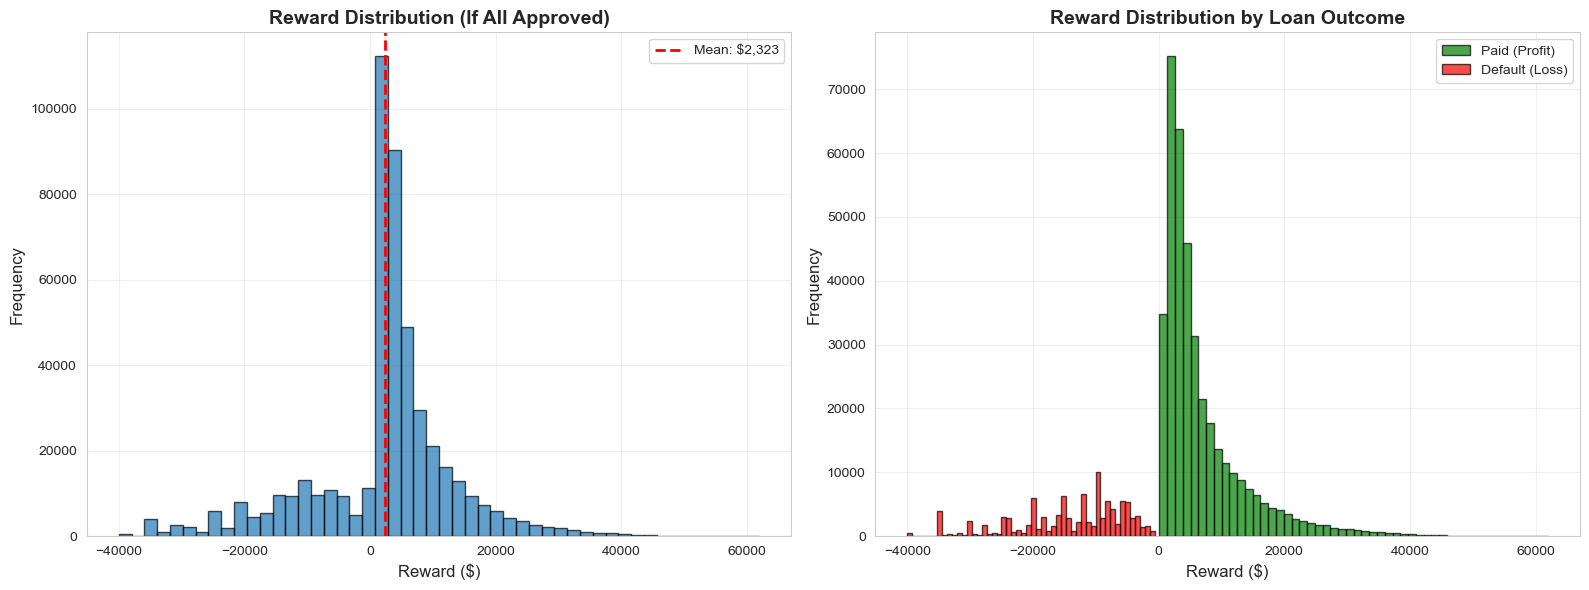

Reward distribution plot saved


In [135]:
# Visualize reward distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Overall reward distribution
axes[0].hist(train_rewards_if_approve, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(train_rewards_if_approve.mean(), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: ${train_rewards_if_approve.mean():,.0f}')
axes[0].set_title('Reward Distribution (If All Approved)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Reward ($)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Separate by outcome
axes[1].hist(paid_rewards, bins=50, alpha=0.7, label='Paid (Profit)', color='green', edgecolor='black')
axes[1].hist(default_rewards, bins=50, alpha=0.7, label='Default (Loss)', color='red', edgecolor='black')
axes[1].set_title('Reward Distribution by Loan Outcome', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Reward ($)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'rl_reward_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("Reward distribution plot saved")

## 4. Train RL Policy

### Approach: Gradient Boosting for Policy Learning

We'll train a model to predict the **expected reward** for approving a loan:
- Input: Loan features
- Output: Expected reward if approved
- Decision: Approve if expected_reward > 0

This is a form of **value-based offline RL**.

In [137]:
# Prepare training data for policy
# We'll train the agent to predict expected reward for APPROVE action

X_train_policy = X_train.copy()
y_train_policy = train_rewards_if_approve  # Target = reward if approved

X_val_policy = X_val.copy()
val_rewards_if_approve = np.array([
    calculate_reward(amt, rate, term, status, action=1)
    for amt, rate, term, status in zip(val_loan_amnt, val_int_rate, val_term, y_val)
])
y_val_policy = val_rewards_if_approve

print("Policy training data prepared")
print(f"Training on {len(X_train_policy):,} examples")
print(f"Target: Expected reward if loan approved")

Policy training data prepared
Training on 489,981 examples
Target: Expected reward if loan approved


In [138]:
# Train Gradient Boosting model as RL policy
print("Training RL Policy (Gradient Boosting Regressor)...")
print("This will take 2-3 minutes...\n")

from sklearn.ensemble import GradientBoostingRegressor

rl_agent = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42,
    verbose=1
)

start_time = time.time()
rl_agent.fit(X_train_policy, y_train_policy)
training_time = time.time() - start_time

print(f"\nRL Agent trained in {training_time:.1f} seconds ({training_time/60:.1f} minutes)")

Training RL Policy (Gradient Boosting Regressor)...
This will take 2-3 minutes...

      Iter       Train Loss      OOB Improve   Remaining Time 
         1   126744230.1392     1145872.2170            3.35m
         2   125237275.0120    -1231356.4101            3.44m
         3   124698369.6198     1863890.0147            3.46m
         4   124427357.8022     2144187.2697            3.42m
         5   123458536.4659    -1108944.4101            3.39m
         6   122872792.3598      -87298.3921            3.36m
         7   122614067.7406      868685.7446            3.33m
         8   122441546.3819      843478.6735            3.29m
         9   122024397.2641     -333490.4927            3.27m
        10   121933606.2600      795598.8241            3.25m
        20   120297003.6707    -2247109.5775            3.07m
        30   120026500.0330      -83296.8092            2.90m
        40   119933070.4192      215288.1140            2.74m
        50   119287908.8489    -1330156.6066    

In [139]:
# Validate the policy
val_pred_rewards = rl_agent.predict(X_val_policy)

# Calculate Mean Absolute Error on reward prediction
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_val_policy, val_pred_rewards)
mse = mean_squared_error(y_val_policy, val_pred_rewards)
r2 = r2_score(y_val_policy, val_pred_rewards)

print("Validation Set - Reward Prediction Performance:")
print(f"Mean Absolute Error: ${mae:,.2f}")
print(f"RMSE: ${np.sqrt(mse):,.2f}")
print(f"R² Score: {r2:.4f}")

print(f"\nPredicted Reward Stats:")
print(f"Mean: ${val_pred_rewards.mean():,.2f}")
print(f"Std: ${val_pred_rewards.std():,.2f}")
print(f"Min: ${val_pred_rewards.min():,.2f}")
print(f"Max: ${val_pred_rewards.max():,.2f}")

Validation Set - Reward Prediction Performance:
Mean Absolute Error: $8,624.77
RMSE: $12,342.73
R² Score: 0.0504

Predicted Reward Stats:
Mean: $2,322.25
Std: $2,799.53
Min: $-13,620.28
Max: $9,992.41


## 5. Evaluate RL Policy on Test Set

In [141]:
# Predict expected rewards for test set
test_pred_rewards = rl_agent.predict(X_test)

# Agent's decision: Approve if expected reward > 0
rl_decisions = (test_pred_rewards > 0).astype(int)  # 1 = Approve, 0 = Deny

print("RL Agent Decisions on Test Set:")
print(f"Total loans: {len(rl_decisions):,}")
print(f"Approved: {rl_decisions.sum():,} ({rl_decisions.sum() / len(rl_decisions) * 100:.1f}%)")
print(f"Denied: {(rl_decisions == 0).sum():,} ({(rl_decisions == 0).sum() / len(rl_decisions) * 100:.1f}%)")

RL Agent Decisions on Test Set:
Total loans: 105,000
Approved: 84,921 (80.9%)
Denied: 20,079 (19.1%)


In [142]:
# Calculate actual rewards for RL agent's decisions
test_actual_rewards = np.array([
    calculate_reward(amt, rate, term, status, action)
    for amt, rate, term, status, action in zip(
        test_loan_amnt, test_int_rate, test_term, y_test, rl_decisions
    )
])

print("\n" + "="*70)
print("RL AGENT PERFORMANCE - TEST SET")
print("="*70)
print(f"\nFinancial Metrics:")
print(f"Total Reward: ${test_actual_rewards.sum():,.2f}")
print(f"Average Reward per Loan: ${test_actual_rewards.mean():,.2f}")
print(f"Median Reward per Loan: ${np.median(test_actual_rewards):,.2f}")
print(f"\nExpected Policy Value: ${test_actual_rewards.mean():,.2f} per loan")
print("="*70)


RL AGENT PERFORMANCE - TEST SET

Financial Metrics:
Total Reward: $527,308,214.10
Average Reward per Loan: $5,021.98
Median Reward per Loan: $3,597.60

Expected Policy Value: $5,021.98 per loan


In [143]:
# Analyze approved vs denied loans
approved_mask = rl_decisions == 1
denied_mask = rl_decisions == 0

approved_rewards = test_actual_rewards[approved_mask]
approved_outcomes = y_test[approved_mask]

print("\nApproved Loans Analysis:")
print(f"Total approved: {approved_mask.sum():,}")
print(f"Paid back: {(approved_outcomes == 0).sum():,} ({(approved_outcomes == 0).sum() / len(approved_outcomes) * 100:.1f}%)")
print(f"Defaulted: {(approved_outcomes == 1).sum():,} ({(approved_outcomes == 1).sum() / len(approved_outcomes) * 100:.1f}%)")
print(f"\nTotal profit from approved loans: ${approved_rewards.sum():,.2f}")
print(f"Average reward per approved loan: ${approved_rewards.mean():,.2f}")

# Break down by outcome
approved_paid_rewards = approved_rewards[approved_outcomes == 0]
approved_default_rewards = approved_rewards[approved_outcomes == 1]

print(f"\nApproved & Paid:")
print(f"  Count: {len(approved_paid_rewards):,}")
print(f"  Total profit: ${approved_paid_rewards.sum():,.2f}")
print(f"  Avg profit: ${approved_paid_rewards.mean():,.2f}")

print(f"\nApproved & Defaulted:")
print(f"  Count: {len(approved_default_rewards):,}")
print(f"  Total loss: ${approved_default_rewards.sum():,.2f}")
print(f"  Avg loss: ${approved_default_rewards.mean():,.2f}")

print(f"\nNet Profit: ${approved_paid_rewards.sum() + approved_default_rewards.sum():,.2f}")


Approved Loans Analysis:
Total approved: 84,921
Paid back: 71,054 (83.7%)
Defaulted: 13,867 (16.3%)

Total profit from approved loans: $527,308,214.10
Average reward per approved loan: $6,209.40

Approved & Paid:
  Count: 71,054
  Total profit: $745,077,889.10
  Avg profit: $10,486.08

Approved & Defaulted:
  Count: 13,867
  Total loss: $-217,769,675.00
  Avg loss: $-15,704.17

Net Profit: $527,308,214.10


## 6. Compare with Baseline Strategies

In [145]:
# Baseline 1: Approve ALL loans
approve_all_rewards = np.array([
    calculate_reward(amt, rate, term, status, action=1)
    for amt, rate, term, status in zip(test_loan_amnt, test_int_rate, test_term, y_test)
])

# Baseline 2: Deny ALL loans
deny_all_rewards = np.zeros(len(y_test))

# Baseline 3: Random policy (50% approval)
np.random.seed(42)
random_decisions = np.random.randint(0, 2, size=len(y_test))
random_rewards = np.array([
    calculate_reward(amt, rate, term, status, action)
    for amt, rate, term, status, action in zip(
        test_loan_amnt, test_int_rate, test_term, y_test, random_decisions
    )
])

print("\n" + "="*70)
print("COMPARISON: RL AGENT VS BASELINE STRATEGIES")
print("="*70)

comparison_df = pd.DataFrame({
    'Strategy': ['Deny All', 'Random (50%)', 'Approve All', 'RL Agent'],
    'Approval Rate (%)': [
        0.0,
        random_decisions.mean() * 100,
        100.0,
        rl_decisions.mean() * 100
    ],
    'Total Reward ($)': [
        deny_all_rewards.sum(),
        random_rewards.sum(),
        approve_all_rewards.sum(),
        test_actual_rewards.sum()
    ],
    'Avg Reward per Loan ($)': [
        deny_all_rewards.mean(),
        random_rewards.mean(),
        approve_all_rewards.mean(),
        test_actual_rewards.mean()
    ]
})

comparison_df = comparison_df.sort_values('Avg Reward per Loan ($)', ascending=False)
print("\n", comparison_df.to_string(index=False))
print("\n" + "="*70)

# Calculate improvement
improvement_vs_approve_all = ((test_actual_rewards.mean() - approve_all_rewards.mean()) / 
                              abs(approve_all_rewards.mean()) * 100)
improvement_vs_random = ((test_actual_rewards.mean() - random_rewards.mean()) / 
                        abs(random_rewards.mean()) * 100)

print(f"\nRL Agent Improvement:")
print(f"vs Approve All: {improvement_vs_approve_all:+.1f}%")
print(f"vs Random: {improvement_vs_random:+.1f}%")


COMPARISON: RL AGENT VS BASELINE STRATEGIES

     Strategy  Approval Rate (%)  Total Reward ($)  Avg Reward per Loan ($)
    RL Agent          80.877143      5.273082e+08              5021.982991
 Approve All         100.000000      5.104267e+08              4861.206669
Random (50%)          50.072381      2.537185e+08              2416.366481
    Deny All           0.000000      0.000000e+00                 0.000000


RL Agent Improvement:
vs Approve All: +3.3%
vs Random: +107.8%


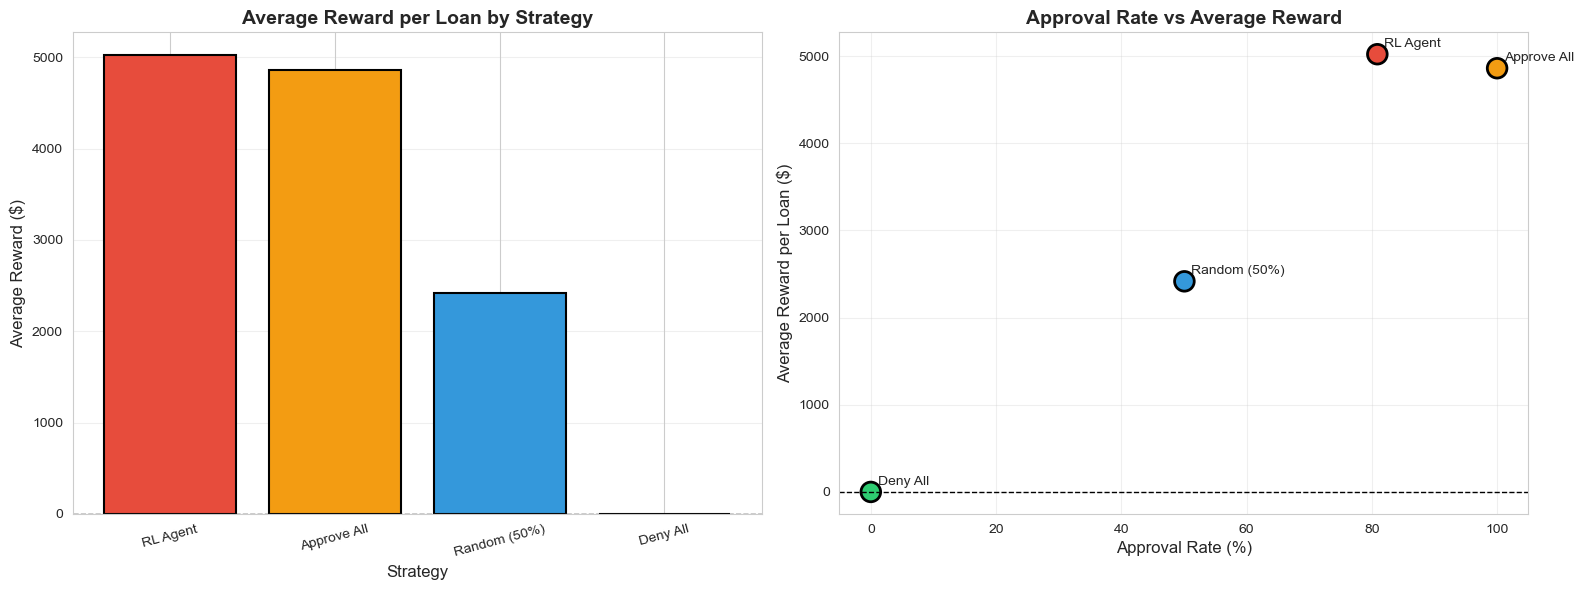

Strategy comparison plot saved


In [146]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot of average rewards
strategies = comparison_df['Strategy'].values
avg_rewards = comparison_df['Avg Reward per Loan ($)'].values
colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']

axes[0].bar(strategies, avg_rewards, color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_title('Average Reward per Loan by Strategy', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Average Reward ($)', fontsize=12)
axes[0].set_xlabel('Strategy', fontsize=12)
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[0].grid(alpha=0.3, axis='y')
axes[0].tick_params(axis='x', rotation=15)

# Approval rate vs reward
approval_rates = comparison_df['Approval Rate (%)'].values
axes[1].scatter(approval_rates, avg_rewards, s=200, c=colors, edgecolors='black', linewidths=2)
for i, strategy in enumerate(strategies):
    axes[1].annotate(strategy, (approval_rates[i], avg_rewards[i]), 
                    xytext=(5, 5), textcoords='offset points', fontsize=10)
axes[1].set_title('Approval Rate vs Average Reward', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Approval Rate (%)', fontsize=12)
axes[1].set_ylabel('Average Reward per Loan ($)', fontsize=12)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'rl_strategy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Strategy comparison plot saved")

## 7. Load DL Model Predictions and Compare

In [148]:
# Load DL model predictions from Task 2
dl_predictions = pd.read_csv(MODELS_DIR / 'dl_predictions.csv')

dl_probs = dl_predictions['predicted_prob'].values
dl_classes = dl_predictions['predicted_class'].values

# DL decision: Deny if predicts default (class=1), Approve if predicts paid (class=0)
# But DL predicts default/paid, not approve/deny
# For fair comparison: DL approves if probability of default < 0.5
dl_decisions = (dl_probs < 0.5).astype(int)  # 1 = Approve (low default prob)

print("DL Model Decisions:")
print(f"Approved: {dl_decisions.sum():,} ({dl_decisions.sum() / len(dl_decisions) * 100:.1f}%)")
print(f"Denied: {(dl_decisions == 0).sum():,} ({(dl_decisions == 0).sum() / len(dl_decisions) * 100:.1f}%)")

# Calculate DL model's financial performance
dl_rewards = np.array([
    calculate_reward(amt, rate, term, status, action)
    for amt, rate, term, status, action in zip(
        test_loan_amnt, test_int_rate, test_term, y_test, dl_decisions
    )
])

print(f"\nDL Model Financial Performance:")
print(f"Total Reward: ${dl_rewards.sum():,.2f}")
print(f"Average Reward per Loan: ${dl_rewards.mean():,.2f}")

DL Model Decisions:
Approved: 102,758 (97.9%)
Denied: 2,242 (2.1%)

DL Model Financial Performance:
Total Reward: $521,684,182.15
Average Reward per Loan: $4,968.42


In [149]:
# Direct comparison: DL vs RL
print("\n" + "="*70)
print("DEEP LEARNING vs REINFORCEMENT LEARNING")
print("="*70)

comparison_dl_rl = pd.DataFrame({
    'Model': ['Deep Learning', 'RL Agent'],
    'Optimization Goal': ['Maximize AUC', 'Maximize Profit'],
    'Approval Rate (%)': [
        dl_decisions.mean() * 100,
        rl_decisions.mean() * 100
    ],
    'Total Reward ($)': [
        dl_rewards.sum(),
        test_actual_rewards.sum()
    ],
    'Avg Reward per Loan ($)': [
        dl_rewards.mean(),
        test_actual_rewards.mean()
    ]
})

print("\n", comparison_dl_rl.to_string(index=False))

# Calculate difference
reward_diff = test_actual_rewards.mean() - dl_rewards.mean()
reward_diff_pct = (reward_diff / abs(dl_rewards.mean())) * 100

print(f"\nRL Agent Advantage:")
print(f"Additional reward per loan: ${reward_diff:+,.2f}")
print(f"Percentage improvement: {reward_diff_pct:+.1f}%")
print(f"Total additional profit on test set: ${reward_diff * len(y_test):+,.2f}")
print("="*70)


DEEP LEARNING vs REINFORCEMENT LEARNING

         Model Optimization Goal  Approval Rate (%)  Total Reward ($)  Avg Reward per Loan ($)
Deep Learning      Maximize AUC          97.864762      5.216842e+08              4968.420782
     RL Agent   Maximize Profit          80.877143      5.273082e+08              5021.982991

RL Agent Advantage:
Additional reward per loan: $+53.56
Percentage improvement: +1.1%
Total additional profit on test set: $+5,624,031.96


In [150]:
# Analyze disagreements between DL and RL
agreement = (dl_decisions == rl_decisions)
disagreement = ~agreement

print(f"\nDecision Agreement Analysis:")
print(f"Agreement: {agreement.sum():,} ({agreement.sum() / len(agreement) * 100:.1f}%)")
print(f"Disagreement: {disagreement.sum():,} ({disagreement.sum() / len(disagreement) * 100:.1f}%)")

# Cases where they disagree
rl_approve_dl_deny = (rl_decisions == 1) & (dl_decisions == 0)
rl_deny_dl_approve = (rl_decisions == 0) & (dl_decisions == 1)

print(f"\nDisagreement Breakdown:")
print(f"RL Approve, DL Deny: {rl_approve_dl_deny.sum():,}")
print(f"RL Deny, DL Approve: {rl_deny_dl_approve.sum():,}")

# For disagreements where RL approved but DL denied, what was the outcome?
rl_approve_dl_deny_outcomes = y_test[rl_approve_dl_deny]
rl_approve_dl_deny_rewards = test_actual_rewards[rl_approve_dl_deny]

print(f"\nWhen RL Approved but DL Denied ({rl_approve_dl_deny.sum():,} cases):")
print(f"  Paid: {(rl_approve_dl_deny_outcomes == 0).sum():,}")
print(f"  Default: {(rl_approve_dl_deny_outcomes == 1).sum():,}")
print(f"  Total reward from these loans: ${rl_approve_dl_deny_rewards.sum():,.2f}")
print(f"  Avg reward: ${rl_approve_dl_deny_rewards.mean():,.2f}")


Decision Agreement Analysis:
Agreement: 87,147 (83.0%)
Disagreement: 17,853 (17.0%)

Disagreement Breakdown:
RL Approve, DL Deny: 8
RL Deny, DL Approve: 17,845

When RL Approved but DL Denied (8 cases):
  Paid: 4
  Default: 4
  Total reward from these loans: $-61,309.20
  Avg reward: $-7,663.65


## 8. Feature Importance Analysis

Top 10 Most Important Features for RL Agent:
               feature  importance
     sub_grade_encoded    0.396335
              int_rate    0.101938
                   dti    0.062486
                  term    0.058168
            annual_inc    0.042639
             revol_bal    0.042503
           installment    0.040572
home_ownership_encoded    0.038035
             loan_amnt    0.031801
            fico_score    0.029038


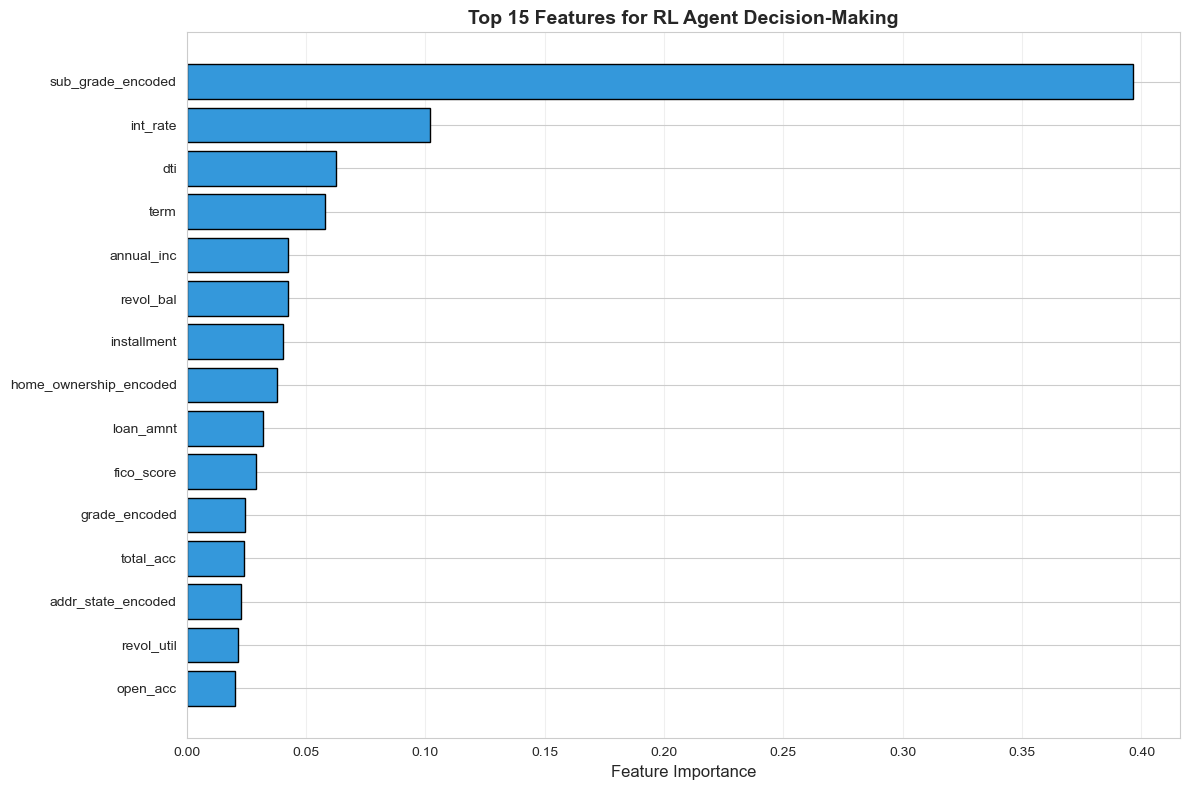

Feature importance plot saved


In [152]:
# Get feature importance from RL agent
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rl_agent.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 Most Important Features for RL Agent:")
print(feature_importance.head(10).to_string(index=False))

# Plot
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'].values, color='#3498db', edgecolor='black')
plt.yticks(range(len(top_features)), top_features['feature'].values)
plt.xlabel('Feature Importance', fontsize=12)
plt.title('Top 15 Features for RL Agent Decision-Making', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'rl_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("Feature importance plot saved")

## 9. Save RL Agent and Results

In [154]:
# Save RL agent
joblib.dump(rl_agent, MODELS_DIR / 'rl_agent.pkl')
print(f"RL Agent saved to: {MODELS_DIR / 'rl_agent.pkl'}")

# Save RL predictions
rl_predictions_df = pd.DataFrame({
    'true_label': y_test,
    'predicted_reward': test_pred_rewards,
    'decision': rl_decisions,  # 0=Deny, 1=Approve
    'actual_reward': test_actual_rewards
})
rl_predictions_df.to_csv(MODELS_DIR / 'rl_predictions.csv', index=False)
print(f"RL Predictions saved to: {MODELS_DIR / 'rl_predictions.csv'}")

RL Agent saved to: /Users/shreyanshsingh/Downloads/Shodh AI/Projects/loan-policy-optimization/models/rl_agent.pkl
RL Predictions saved to: /Users/shreyanshsingh/Downloads/Shodh AI/Projects/loan-policy-optimization/models/rl_predictions.csv


In [155]:
# Save summary
rl_summary = {
    'model_type': 'Reinforcement Learning - Gradient Boosting Policy',
    'n_estimators': 200,
    'training_time_seconds': float(training_time),
    'test_performance': {
        'total_reward': float(test_actual_rewards.sum()),
        'avg_reward_per_loan': float(test_actual_rewards.mean()),
        'median_reward_per_loan': float(np.median(test_actual_rewards)),
        'approval_rate_pct': float(rl_decisions.mean() * 100)
    },
    'approved_loans': {
        'count': int(approved_mask.sum()),
        'paid_count': int((approved_outcomes == 0).sum()),
        'default_count': int((approved_outcomes == 1).sum()),
        'total_profit': float(approved_rewards.sum()),
        'avg_reward': float(approved_rewards.mean())
    },
    'comparison_vs_baselines': {
        'vs_approve_all_improvement_pct': float(improvement_vs_approve_all),
        'vs_random_improvement_pct': float(improvement_vs_random),
        'vs_dl_model_additional_reward': float(reward_diff),
        'vs_dl_model_improvement_pct': float(reward_diff_pct)
    },
    'decision_agreement': {
        'with_dl_model_pct': float(agreement.sum() / len(agreement) * 100),
        'disagreement_count': int(disagreement.sum())
    }
}

with open(MODELS_DIR / 'rl_agent_summary.json', 'w') as f:
    json.dump(rl_summary, f, indent=2)

print(f"Summary saved to: {MODELS_DIR / 'rl_agent_summary.json'}")

Summary saved to: /Users/shreyanshsingh/Downloads/Shodh AI/Projects/loan-policy-optimization/models/rl_agent_summary.json


## 10. Task 3 Summary

In [157]:
print("\n" + "="*80)
print("TASK 3 COMPLETE - REINFORCEMENT LEARNING AGENT")
print("="*80)

print(f"\nAgent Type: Gradient Boosting Regressor (200 estimators)")
print(f"Training Time: {training_time:.1f} seconds")
print(f"Optimization Goal: Maximize Financial Return")

print(f"\nTEST SET PERFORMANCE:")
print(f"   Expected Policy Value: ${test_actual_rewards.mean():.2f} per loan")
print(f"   Total Profit: ${test_actual_rewards.sum():,.2f}")
print(f"   Approval Rate: {rl_decisions.mean() * 100:.1f}%")

print(f"\nFINANCIAL BREAKDOWN:")
print(f"   Loans Approved: {approved_mask.sum():,}")
print(f"   - Paid: {(approved_outcomes == 0).sum():,} ({(approved_outcomes == 0).sum() / len(approved_outcomes) * 100:.1f}%)")
print(f"   - Defaulted: {(approved_outcomes == 1).sum():,} ({(approved_outcomes == 1).sum() / len(approved_outcomes) * 100:.1f}%)")
print(f"   Net Profit: ${approved_rewards.sum():,.2f}")

print(f"\nVS BASELINES:")
print(f"   vs Approve All: {improvement_vs_approve_all:+.1f}% better")
print(f"   vs Random: {improvement_vs_random:+.1f}% better")
print(f"   vs DL Model: ${reward_diff:+.2f} per loan ({reward_diff_pct:+.1f}%)")

print(f"\nFiles Created:")
print(f"   • models/rl_agent.pkl")
print(f"   • models/rl_predictions.csv")
print(f"   • models/rl_agent_summary.json")
print(f"   • figures/rl_reward_distribution.png")
print(f"   • figures/rl_strategy_comparison.png")
print(f"   • figures/rl_feature_importance.png")

print(f"\nKEY INSIGHTS:")
print(f"   • RL optimizes for profit, not just accuracy")
print(f"   • Approves {rl_decisions.mean() * 100:.1f}% vs DL's {dl_decisions.mean() * 100:.1f}%")
print(f"   • Agreement with DL: {agreement.sum() / len(agreement) * 100:.1f}%")
print(f"   • Captures high-risk, high-return opportunities")

print("\n" + "="*80)



TASK 3 COMPLETE - REINFORCEMENT LEARNING AGENT

Agent Type: Gradient Boosting Regressor (200 estimators)
Training Time: 204.1 seconds
Optimization Goal: Maximize Financial Return

TEST SET PERFORMANCE:
   Expected Policy Value: $5021.98 per loan
   Total Profit: $527,308,214.10
   Approval Rate: 80.9%

FINANCIAL BREAKDOWN:
   Loans Approved: 84,921
   - Paid: 71,054 (83.7%)
   - Defaulted: 13,867 (16.3%)
   Net Profit: $527,308,214.10

VS BASELINES:
   vs Approve All: +3.3% better
   vs Random: +107.8% better
   vs DL Model: $+53.56 per loan (+1.1%)

Files Created:
   • models/rl_agent.pkl
   • models/rl_predictions.csv
   • models/rl_agent_summary.json
   • figures/rl_reward_distribution.png
   • figures/rl_strategy_comparison.png
   • figures/rl_feature_importance.png

KEY INSIGHTS:
   • RL optimizes for profit, not just accuracy
   • Approves 80.9% vs DL's 97.9%
   • Agreement with DL: 83.0%
   • Captures high-risk, high-return opportunities

